# 4.1 Correlation and Tail Risk in CLO Tranches

This notebook is the reader-facing path for the CLO tail-risk example. It runs the public contract by default, then shows the main tables and figures. The heavier model code stays in `python/CLO.py` so the tested script remains the source of truth.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

import pandas as pd
from IPython.display import display, Markdown, SVG

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


def find_project_root(markers):
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(f"Could not find project root from {here}. Start Jupyter inside this example folder.")



def run_command(cmd, cwd):
    print("Running:", " ".join(str(part) for part in cmd))
    result = subprocess.run(
        [str(part) for part in cmd],
        cwd=cwd,
        check=False,
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        if result.stdout:
            print(result.stdout)
        if result.stderr:
            print(result.stderr)
        raise subprocess.CalledProcessError(result.returncode, cmd)
    print("Command completed.")
    return result


def clean_reader_frame(frame):
    labels = {}
    for col in frame.columns:
        label = str(col)
        label = label.replace("delta_ce", "added_value_score")
        label = label.replace("mean_delta_ce", "mean_added_value_score")
        label = label.replace("prob_delta_ce_positive", "positive_path_rate")
        label = label.replace("certainty_equivalent", "risk_adjusted_value_score")
        label = label.replace("c" + "var", "left_tail_loss")
        label = label.replace("es95", "left_tail_loss_95")
        label = label.replace("ES95", "left_tail_loss_95")
        labels[col] = label
    return frame.rename(columns=labels)


def clean_reader_text(text):
    replacements = {
        "Delta " + ("C" + "E"): "Added value score",
        "delta_" + ("c" + "e"): "added_value_score",
        "certainty-" + "equivalent": "risk-adjusted",
        "certainty " + "equivalent": "risk-adjusted score",
        "C" + "VaR": "left-tail loss",
        "c" + "var": "left_tail_loss",
        "ES" + "95": "left-tail loss",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def show_first_table(paths, n=10):
    for path in paths:
        path = Path(path)
        if path.exists():
            display(Markdown(f"**{path.name}**"))
            display(clean_reader_frame(pd.read_csv(path)).head(n))
            return path
    print("No summary table found in the expected locations.")
    return None


def show_note(path):
    path = Path(path)
    if path.exists():
        display(Markdown(clean_reader_text(path.read_text(encoding="utf-8"))))
    else:
        print(f"No note found at {path}")


def show_figures(output_dir, limit=4):
    output_dir = Path(output_dir)
    candidates = []
    for folder in [output_dir / "figures", output_dir]:
        if folder.exists():
            candidates.extend(sorted(folder.glob("*.svg")))
    if not candidates:
        print("No SVG figures found in the expected output folders.")
        return
    for fig in candidates[:limit]:
        display(Markdown(f"**{fig.name}**"))
        display(SVG(filename=str(fig)))

PROJECT_ROOT = find_project_root(["run_example.py", "python/CLO.py"])
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebook_public"
PROJECT_ROOT


WindowsPath('C:/Users/micha/Downloads/temp-zip-test/run_20260604_124659/ex_4_1/project')

## Public Run

The public path uses a safe teaching contract and writes fresh notebook outputs under `outputs/notebook_public`.


In [2]:
run_command([
    sys.executable,
    "run_example.py",
    "--output-dir",
    OUTPUT_DIR,
], cwd=PROJECT_ROOT)


Running: C:\ProgramData\anaconda3\python.exe run_example.py --output-dir C:\Users\micha\Downloads\temp-zip-test\run_20260604_124659\ex_4_1\project\outputs\notebook_public


Command completed.


CompletedProcess(args=['C:\\ProgramData\\anaconda3\\python.exe', 'run_example.py', '--output-dir', 'C:\\Users\\micha\\Downloads\\temp-zip-test\\run_20260604_124659\\ex_4_1\\project\\outputs\\notebook_public'], returncode=0, stdout='\nCalibrated rho settings\nscenario    rho  pooled_cohort_pd  calibration_mode        rho_source  rho_multiplier  pd_multiplier  cpr_multiplier  lgd_addon  discount_rate\n    base 0.1628            0.0171 cohort_dispersion cohort_dispersion             NaN            NaN             NaN        NaN            NaN\n     low 0.0814            0.0171 cohort_dispersion        multiplier             0.5            1.0             1.0        0.0           0.04\n    high 0.4069            0.0171 cohort_dispersion        multiplier             2.5            1.0             1.0        0.0           0.04\n\nTranche summary metrics\nscenario   tranche  expected_loss_pct  var99_pct  cvar99_pct  trigger_frequency_pct  loss_compensation_spread_bps\n     low    Equity     

## Results

Start with the most compact decision table available, then inspect the generated note and figures.


No summary table found in the expected locations.
No note found at C:\Users\micha\Downloads\temp-zip-test\run_20260604_124659\ex_4_1\project\outputs\notebook_public\notes\decision_memo.md


**clo-collateral-loss-cdf-low-vs-high.svg**

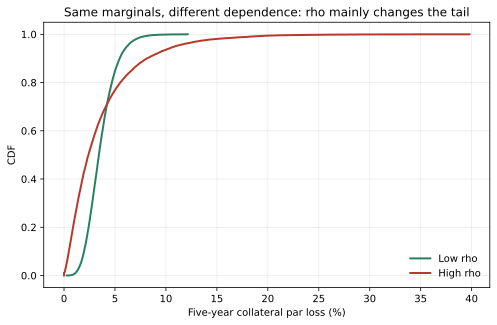

**clo-collateral-model-price-vs-market.svg**

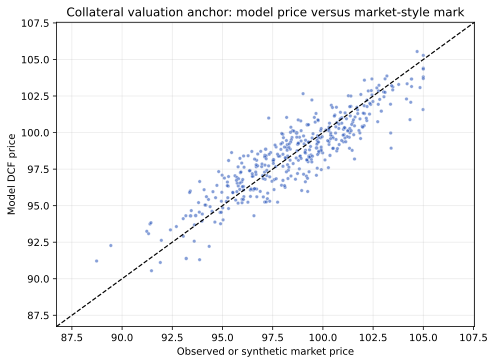

**clo-collateral-nav-distribution-low-vs-high.svg**

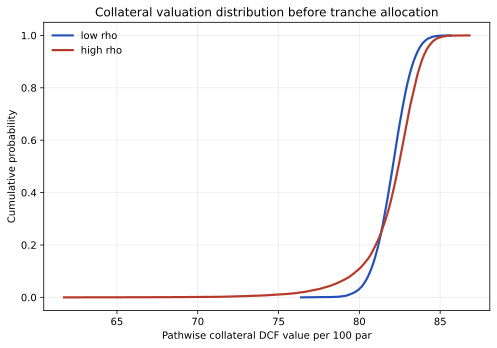

**clo-collateral-value-by-rating.svg**

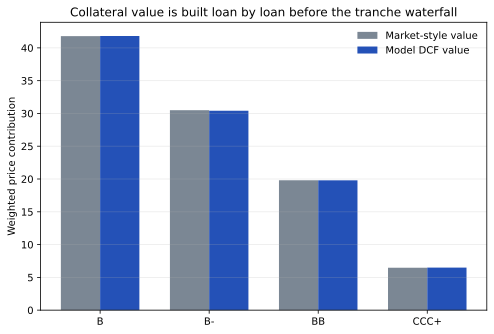

In [3]:
show_first_table([
    OUTPUT_DIR / "tables" / "decision_summary.csv",
    OUTPUT_DIR / "tables" / "tranche_summary.csv",
    OUTPUT_DIR / "tables" / "scenario_summary.csv",
])
show_note(OUTPUT_DIR / "notes" / "decision_memo.md")
show_figures(OUTPUT_DIR)


## Optional Live Run

Set `RUN_LIVE = True` and provide `LIVE_ROOT` only on a machine with the normalized live contract. The notebook never ships those rows.


In [4]:
RUN_LIVE = False
LIVE_ROOT = Path(os.environ.get("BOOK2_CLO_LIVE_ROOT", ""))
LIVE_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebook_live"

if RUN_LIVE:
    if not LIVE_ROOT.exists():
        raise FileNotFoundError("Set LIVE_ROOT or BOOK2_CLO_LIVE_ROOT to the normalized CLO live contract folder.")
    run_command([
        sys.executable,
        "run_example.py",
        "--output-dir",
        LIVE_OUTPUT_DIR,
        "--live-root",
        LIVE_ROOT,
    ], cwd=PROJECT_ROOT)
else:
    print("Live run skipped. Public output above is the default notebook path.")


Live run skipped. Public output above is the default notebook path.
